# Гибридизация алгоритмов

## Методы гибридизации

На текущий момент в Генезис реализованы следующие методы гибридизации:
* Бустинг
* Стекинг

### Бустинг

**Boosting** — последовательный ансамбль моделей, где каждая следующая модель обучается на ошибках предыдущей, а финальное предсказание получается комбинацией выходов всех моделей.

```{mermaid}
graph LR
    Data[Данные]
    Model1[Модель 1]
    Model2[Модель 2]
    Model3[Модель 3]
    Combiner[Комбинирование]
    Data --> Model1
    Model1 --> Model2
    Model2 --> Model3
    Model1 --> Combiner
    Model2 --> Combiner
    Model3 --> Combiner
    Combiner --> Output[Выход]
```

### Стекинг

**Stacking** — параллельный ансамбль разных моделей, чьи предсказания затем передаются на вход мета-модели, выносящей итоговое решение.

```{mermaid}
graph LR
    Data[Данные]
    Base1[Базовая модель 1]
    Base2[Базовая модель 2]
    Base3[Базовая модель 3]
    Meta[Мета-модель]
    Data --> Base1
    Data --> Base2
    Data --> Base3
    Base1 --> Meta
    Base2 --> Meta
    Base3 --> Meta
    Meta --> Output[Выход]
```

---

Данные подходы реализованы в классе `genesis.Hybridization`.

## Документация классов

### Класс `Hybridization`

```python
class Hybridization(MCLPBase):
    '''
    Реализация базового алгоритма MCLP как гибрида

    Является функцией гибридизации алгоритмов BestPoints, MCLP и LSCP,
    методами бустинга и беггинга, т.е. последовательного выполнения функций и передачи полученного 
    результата далее.
    '''
    def __init__(self,
                 state_function:        StateBase,
                 metric_function:       MetricBase,
                 functions:             list,
                 type_of_hybrid:        str        = 'Boosting',
                 function_end_function: callable   = None,
                 **kwargs):
        '''
        ## Аргументы

        `functions`: list
            Список функций для гибридизации.

        `type_of_hybrid`: str = 'Boosting'  
            Тип гибридизации. Возможные варианты: 'Boosting' или 'Stacking'.
            * 'Boosting' - метод бустинга, т.е. последовательного выполнения функций и передачи полученного 
              результата далее.
            * 'Stacking' - метод стекинга, т.е. параллельного выполнения функций и выбора лучшего результата.  

        `state_function`: StateBase = None
            Функция для расчета состояния.

        `metric_function`: MetricBase = None
            Функция для расчета основной метрики.

        `function_end_function`: callable = None
            Функция для выполнения после выполнения каждой функции.

        `**kwargs`
            Дополнительные аргументы для функций.
        '''
    def __call__(self,
                 env:           nx.Graph,
                 dynamic_nodes: dict,
                 static_nodes:  dict      = None,
                 area:          pd.Series = None,
                 **kwargs):
        '''
        ## Аргументы

        `env`: nx.Graph  
            Граф улично-дорожной сети

        `dynamic_nodes`: dict  
            Список стартовых узлов графа, в которых размещены 
            подразделения, оптимальные места которых следует определить.

        `static_nodes`: dict = None  
            Список стартовых узлов графа, в которых размещены 
            подразделения, изменять размещение которых не следует.

        `area`: pd.Series = None  
            Маска узлов графа. Значениями True отмечены узлы — цели расчёта. 
            Если не указана, расчёт производится для всех узлов.

        ## Возвращает

        `best_dynamic_nodes, best_metric`: tuple[list|dict, float]  
            Список или словарь лучших мест размещения и значение метрики для них.
        '''
```

### Класс `AdapterBLP2MCLP`

Класс `AdapterBLP2MCLP` необходим для приведенеия алгоритмов BLP к интерфейсу алгоритмов MCLP, LSCP. Это позволяет использовать их в едином гибридном алгоритме.

```python
class AdapterBLP2MCLP(MCLPBase):
    '''
    Адаптер алгоритмов BLP к MCLP.

    Позволяет использовать алгоритмы BestPointsBase как MCLPBase.
    '''
    def __init__(self,
                 blp_function:    BestPointsBase,
                 state_function:  StateBase      = None,
                 metric_function: MetricBase     = None,
                 **kwargs):
        '''
        Перечень аргументов соответствует алгоритму BLP, переданному через аргумент `blp_function`.

        ## Аргументы
        
        `blp_function`: BestPointsBase  
            Функция, реализующая алгоритм BLP.

        `state_function`: StateBase  
            Функция расчета состояния окружения.

        `metric_function`: MetricBase  
            Функция расчета метрики.

        `**kwargs`  
            Прочие аргументы, определяющиеся реализацией blp_function.
        '''
    def __call__(self,
                 env,
                 area                = None,
                 dynamic_nodes: dict = None,
                 static_nodes:  dict = None,
                 **kwargs) -> tuple[dict, int|float]:
        '''
        # Аргументы

        `env`: nx.Graph  
            Граф улично-дорожной сети

        `area`: pd.Series = None  
            Маска узлов графа. Значениями True отмечены узлы — цели расчёта.

        `dynamic_nodes`: dict  
            Список стартовых узлов графа, в которых размещены 
            подразделения, оптимальные места которых следует определить.

        `static_nodes`: dict = None  
            Список стартовых узлов графа, в которых размещены 
            подразделения, изменять размещение которых не следует.  
            Для BLP не используется.

        `**kwargs`  
            Прочие аргументы, определяющиеся реализацией blp_function.
        '''
```

Подключение библиотек

In [1]:
import networkx as nx
import numpy as np
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely

Загрузка данных

In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ населенного пункта
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Построение гибрида для решения задачи BLP

### Расчет с использованием гибридного алгоритма на основе **бустинга**.

In [3]:
import pandas as pd
from genesis.best_points import BestNodeHillClimbing, BestNodesHalfDiameter
from genesis.hybridisation import AdapterBLP2MCLP, Hybridization
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.states import FirstArrivalUnitState


# Сборка гибридного алгоритма
#========================================================================
# Основная метрика, в данном случае - покрытие территории
main_metric = CoverIndex()  
# Функция - гибридизации
hybrid = Hybridization(
    state_function = FirstArrivalUnitState(),
    metric_function = main_metric,
    functions = [],
    function_end_function = lambda turn, best_metric, cur_metric, best_nodes: 
        print(f'{turn}: {best_metric}, {cur_metric}, {best_nodes}'),
    )


# Добавление функций в гибрид
## Добавляем функцию: BNHD
hybrid.append(
    AdapterBLP2MCLP(
        BestNodesHalfDiameter()
    )
)
## Добавляем функцию: HC+max
hybrid.append(
    AdapterBLP2MCLP(
        BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
    )
)
## Добавляем функцию: HC+mean
hybrid.append(
    AdapterBLP2MCLP(
        BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(f=np.max))
    )
)
#========================================================================

# Стартовое размещение
g_nodes_list = list(G.nodes())
start_nodes = {
    g_nodes_list[2000]:'псч-1'
}

# Собственно применение гибрида
best_nodes, best_metric = hybrid(
    env           = G,
    dynamic_nodes = start_nodes
    )

print('Результаты применения гибрида:')
best_nodes, best_metric

0: 5.566874070811079, None, {12011159468: 'псч-1'}
1: 23.236605913771267, 16.765956427943696, {10933881764: 'псч-1'}
2: 23.236605913771267, 46.795052244666174, {10933881764: 'псч-1'}
Результаты применения гибрида:


({10933881764: 'псч-1'}, 23.236605913771267)

### Расчет с использованием гибридного алгоритма на основе **стекинга**.

In [4]:
hybrid.set_type_of_hybrid('Stacking')
best_nodes, best_metric = hybrid(
    env           = G,
    dynamic_nodes = start_nodes
    )

print('Результаты применения гибрида:')
best_nodes, best_metric

0: 5.566874070811079, None, {12011159468: 'псч-1'}
1: 18.253400143163923, 16.5762686838006, {1668774988: 'псч-1'}
2: 18.253400143163923, 47.46519028387051, {1668774988: 'псч-1'}
Результаты применения гибрида:


({1668774988: 'псч-1'}, 18.253400143163923)

### Для решения задачи MCLP

Эпоха: 0, Метрика: 64.8147128462089
Эпоха: 1, Метрика: 66.1802764164969
Эпоха: 2, Метрика: 66.1802764164969
Эпоха: 3, Метрика: 66.1802764164969
Эпоха: 4, Метрика: 66.1802764164969
Эпоха: 5, Метрика: 68.91690986179175
Эпоха: 6, Метрика: 68.91690986179175
Эпоха: 7, Метрика: 69.77589339794064
Эпоха: 8, Метрика: 69.77589339794064
Эпоха: 9, Метрика: 69.77589339794064
Алгоритм №0: 69.77589339794064, 69.77589339794064
Шаг: 0, Метрика: 72.78784207918066
Шаг: 1, Метрика: 72.78784207918066
Шаг: 2, Метрика: 72.78784207918066
Алгоритм №1: 72.78784207918066, 72.78784207918066
Шаг: 0, Метрика: 72.80436099333737
Шаг: 1, Метрика: 72.80436099333737
Шаг: 2, Метрика: 72.80436099333737
Алгоритм №2: 72.80436099333737, 72.80436099333737
Результаты применения гибрида:
{904976003: 'псч-3', 1143772744: 'псч-2', 7005944615: 'псч-1', 11098488288: 'псч-4'} 72.80436099333737
ИП-10: 72.80436099333737


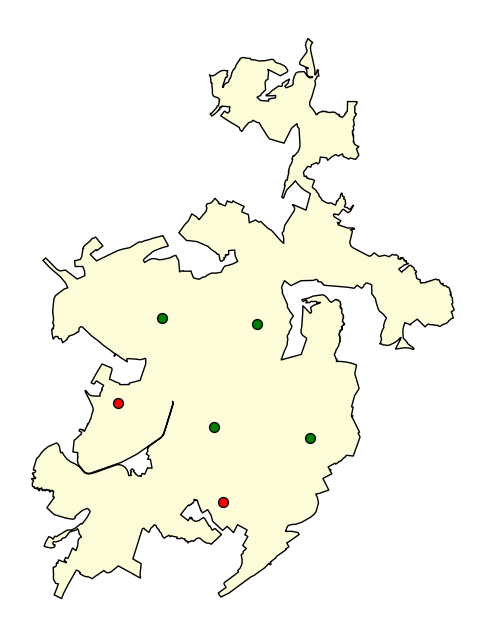

In [5]:
# Функция - гибридизации
from genesis.mclp import BestNodesGA, BestNodesKoptG
from genesis.point_selectors import RandomNodesSelector



# Основная метрика
main_metric = CoverIndex()

# Инициация Гибридного алгоритма
hybrid = Hybridization(
    state_function  = FirstArrivalUnitState(),
    metric_function = main_metric,
    functions       = [],
    function_end_function = lambda turn, best_metric, cur_metric, best_nodes: 
        print(f'Алгоритм №{turn}: {best_metric}, {cur_metric}'),
)
## Добавляем функцию: ГА
hybrid.append(
    BestNodesGA(
        state_function        = FirstArrivalUnitState(),
        metric_function       = main_metric,
        node_selector         = RandomNodesSelector(),
        population_size       = 25,
        epochs                = 10,
        mutation_rate         = 0.5,
        elite_size            = 10,
        epoch_end_function = lambda epoch, best_metric, **kwargs: 
            print(f"Эпоха: {epoch}, Метрика: {best_metric}")
    )
)
## Добавляем функцию: Генезис с оптимизацией по среднему времени прибытия
hybrid.append(
    BestNodesKoptG(
        state_function      = FirstArrivalUnitState(),
        metric_function     = main_metric,
        iterations          = 3,
        best_point_function = BestNodeHillClimbing(
                state_function  = FirstArrivalUnitState(),
                metric_function = ArrivalTime(),    # Среднее время прибытия    
        ),
        iter_calc_end_function = lambda i, best_metric, **kwargs: 
            print(f"Шаг: {i}, Метрика: {best_metric}")
    )
)
## Добавляем функцию: Генезис с оптимизацией по среднему ИП-10
hybrid.append(
    BestNodesKoptG(
        state_function      = FirstArrivalUnitState(),
        metric_function     = main_metric,
        iterations          = 3,
        best_point_function = BestNodeHillClimbing(
                state_function  = FirstArrivalUnitState(),
                metric_function = main_metric,      # Основная метрика: ИП-10
        ),
        iter_calc_end_function = lambda i, best_metric, **kwargs: 
            print(f"Шаг: {i}, Метрика: {best_metric}")
    )
)


# Применение гибридного алгоритма
# Стартовое размещение 
g_nodes_list = list(G.nodes())
dynamic_nodes = {
    g_nodes_list[2000]:'псч-1',
    g_nodes_list[3000]:'псч-2',
    g_nodes_list[4000]:'псч-3',
    g_nodes_list[5000]:'псч-4',
}
static_nodes = {
    g_nodes_list[10000]:'ПСЧ-А',
    g_nodes_list[15000]:'ПСЧ-Б',
}

# Собственно применение гибрида
best_nodes, best_metric = hybrid(
    env           = G,
    dynamic_nodes = dynamic_nodes,
    static_nodes  = static_nodes,
    )

print('Результаты применения гибрида:')
print(best_nodes, best_metric)

# Печать результатов
print('ИП-10:', best_metric)

# Печать карты
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
g_nodes.loc[static_nodes.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

Можно заметить, что использование метрик с различными параметрами позволяет улучшить итоговый результат.

#### Расчет с использованием **стекинга**

Эпоха: 0, Метрика: 63.98876713837344
Эпоха: 1, Метрика: 63.98876713837344
Эпоха: 2, Метрика: 63.98876713837344
Эпоха: 3, Метрика: 63.98876713837344
Эпоха: 4, Метрика: 63.98876713837344
Эпоха: 5, Метрика: 67.69451021419525
Эпоха: 6, Метрика: 67.69451021419525
Эпоха: 7, Метрика: 67.69451021419525
Эпоха: 8, Метрика: 67.69451021419525
Эпоха: 9, Метрика: 71.00379935025605
Алгоритм №0: 71.00379935025605, 71.00379935025605
Шаг: 0, Метрика: 56.599306205605416
Шаг: 1, Метрика: 56.61582511976213
Шаг: 2, Метрика: 56.61582511976213
Алгоритм №1: 71.00379935025605, 56.61582511976213
Шаг: 0, Метрика: 58.840372226199
Шаг: 1, Метрика: 61.03188150432245
Шаг: 2, Метрика: 61.05390672319806
Алгоритм №2: 71.00379935025605, 61.05390672319806
ИП-10: 71.00379935025605


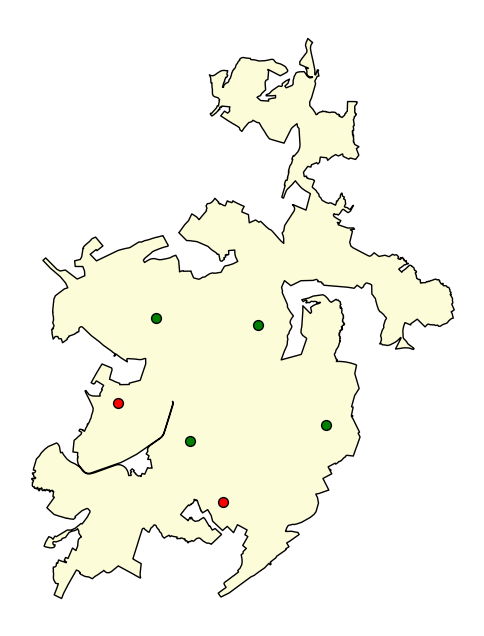

In [6]:
hybrid.set_type_of_hybrid('Stacking')

best_nodes, best_metric = hybrid(
    env           = G,
    dynamic_nodes = dynamic_nodes,
    static_nodes  = static_nodes,
    )

# Печать результатов
print('ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
g_nodes.loc[static_nodes.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

На данном примере стекинг показал несколько худшие результаты. Однако так может быть не всегда.

Комбинируя различные алгоритмы можно получить достаточно приемлемые решения для разных задач.